# Flood Prediction in Metro Manila: SMOTE, Tuning and Evaluation

Compares five classifiers (Logistic Regression, SVM, KNN, Naive Bayes, Random Forest) on the Metro Manila daily flood dataset.

- Stratified 80/20 train/test split.
- Each model sits in one pipeline: `StandardScaler` -> `SMOTE` -> model. `GridSearchCV` (5-fold, scored on F1) tunes the hyperparameters. Because SMOTE is inside the pipeline, it only resamples the training folds and never touches validation folds or the test set.
- Final evaluation on the untouched test set: accuracy, precision, recall, F1, ROC-AUC and confusion matrices.

Full exploratory analysis is in `01_eda_and_baseline.ipynb`. Data: see `data/README.md`. Random seeds are fixed (`random_state=42`) so results can be reproduced.

## 1. Load data and quick checks

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('../data/flood_prediction.csv')

In [3]:
df.shape

(7308, 7)

In [4]:
df.describe()

,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence
count,7308.000000,7308.000000,7308.000000,7308.000000,7308.000000
mean,10.052874,1.266379,15.184989,17.000000,0.018062
std,7.101769,0.902239,5.994044,15.557414,0.133186
min,0.100000,0.500000,5.000000,5.000000,0.000000
25%,4.900000,0.500000,10.900000,5.000000,0.000000
50%,8.400000,1.000000,14.900000,10.000000,0.000000
75%,13.500000,1.800000,19.100000,22.000000,0.000000
max,52.700000,6.400000,39.700000,43.000000,1.000000


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
print(df.dtypes)

Date                datetime64[ns]
Location                    object
Rainfall_mm                float64
WaterLevel_m               float64
SoilMoisture_pct           float64
Elevation_m                  int64
FloodOccurrence              int64
dtype: object


In [7]:
df['FloodOccurrence'].value_counts(normalize=True)

FloodOccurrence
0    0.981938
1    0.018062
Name: proportion, dtype: float64

### Feature distributions, outliers and correlations

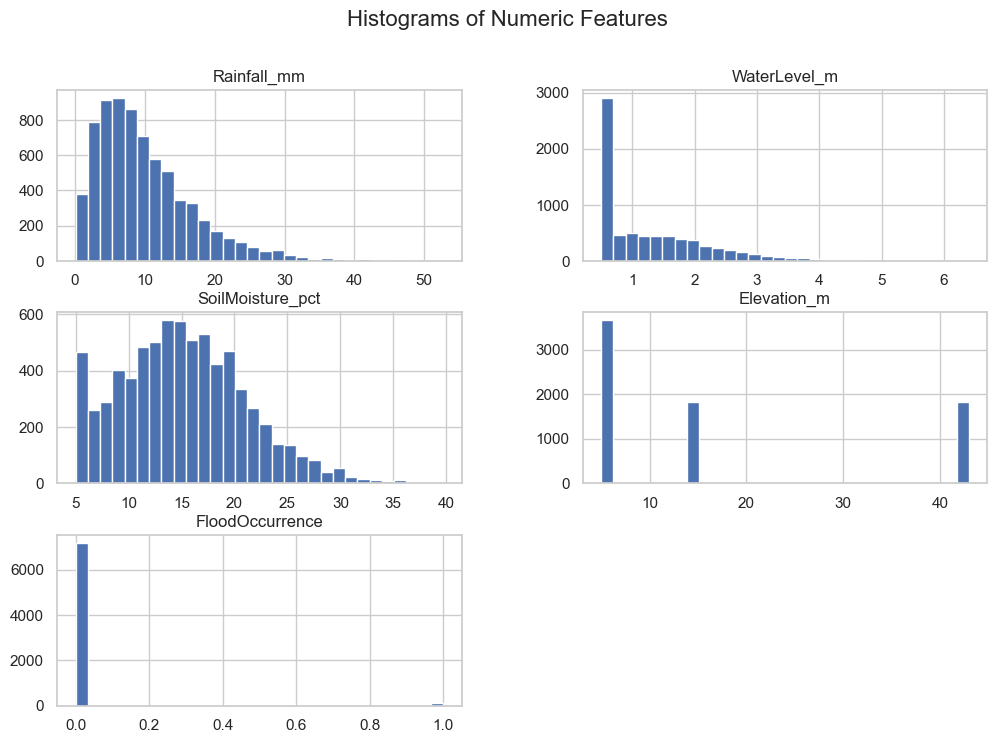

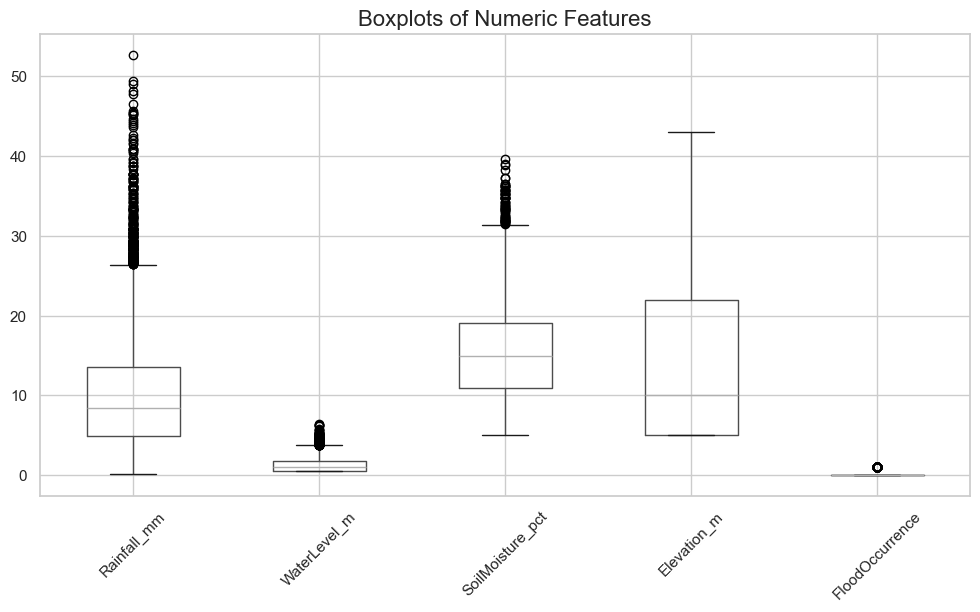

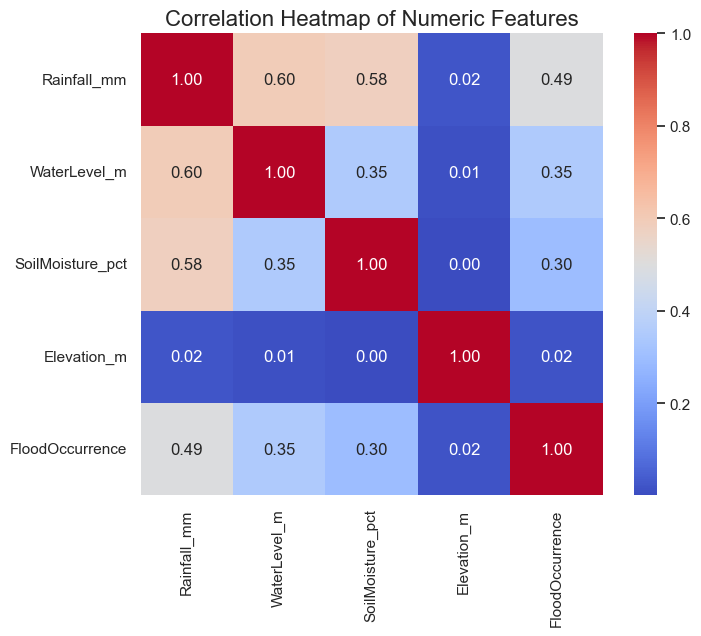

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# List of numeric columns
numeric_cols = ['Rainfall_mm', 'WaterLevel_m', 'SoilMoisture_pct', 'Elevation_m', 'FloodOccurrence']

# -----------------------------
# 1️⃣ HISTOGRAMS
# -----------------------------
df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.show()

# -----------------------------
# 2️⃣ BOXPLOTS
# -----------------------------
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title("Boxplots of Numeric Features", fontsize=16)
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 3️⃣ CORRELATION HEATMAP
# -----------------------------
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.show()


## 2. Setup

Imports for modelling. `imblearn` comes from the `imbalanced-learn` package.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, auc)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# SMOTE + Pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

Features and target.

In [10]:
features = ['Rainfall_mm', 'WaterLevel_m', 'SoilMoisture_pct', 'Elevation_m']
target = 'FloodOccurrence'

X = df[features]
y = df[target]

## 3. Train/test split

80/20, stratified so both sets keep the same share of flood days (about 1.8%).

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 4. Models and hyperparameter grids

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Hyperparameter grids
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"]
    },
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": ["scale", "auto"]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]  # 1=Manhattan, 2=Euclidean
    },
    "Naive Bayes": {
        # GaussianNB doesn't have many params; this is optional
        "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    }
}

## 5. Grid search with 5-fold cross-validation

For each model: scale, oversample the training folds with SMOTE, fit, and pick the hyperparameters with the best cross-validated F1. The best pipeline is then evaluated once on the test set.

In [13]:
best_models = {}
results = []

for name, base_model in models.items():
    print("\n=================================================")
    print(f" Running GridSearchCV for: {name}")
    print("=================================================")

    # Pipeline: Scale -> SMOTE -> Model
    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", base_model)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=5,
        scoring="f1",
        n_jobs=-1,
        verbose=1
    )

    # Fit on training data
    grid.fit(X_train, y_train)

    print("Best Parameters:", grid.best_params_)
    print("Best CV F1 Score:", grid.best_score_)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix (Test Set):")
    print(confusion_matrix(y_test, y_pred))


 Running GridSearchCV for: Logistic Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV F1 Score: 0.9331915754146678

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1436
           1       0.87      1.00      0.93        26

    accuracy                           1.00      1462
   macro avg       0.93      1.00      0.96      1462
weighted avg       1.00      1.00      1.00      1462

Confusion Matrix (Test Set):
[[1432    4]
 [   0   26]]

 Running GridSearchCV for: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV F1 Score: 0.9731313131313131

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    

## 6. Results table

In [14]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
print("\n\n==============================")
print("MODEL PERFORMANCE SUMMARY")
print("==============================")
print(results_df)



MODEL PERFORMANCE SUMMARY
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.997264   0.866667  1.000000  0.928571  1.000000
1                  SVM  0.998632   0.928571  1.000000  0.962963  1.000000
2                  KNN  0.993160   0.766667  0.884615  0.821429  0.978854
3          Naive Bayes  0.959644   0.305882  1.000000  0.468468  0.999518
4        Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000


## 7. Confusion matrices

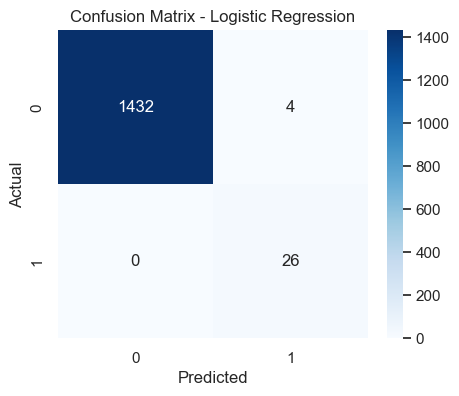

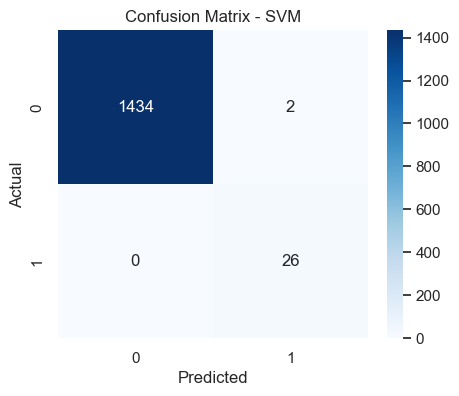

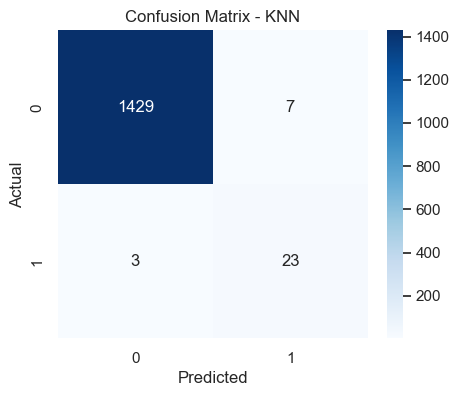

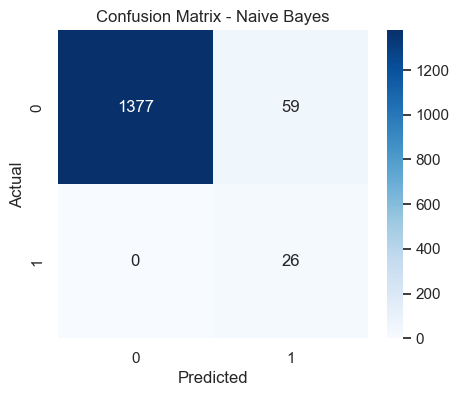

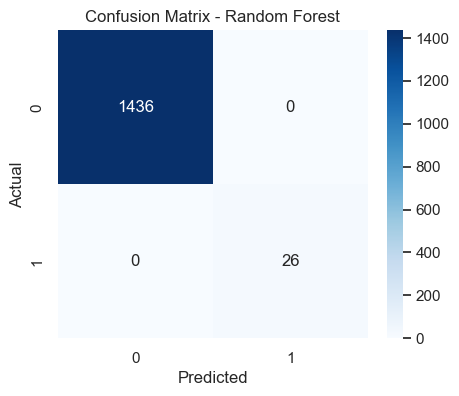

In [15]:
import seaborn as sns

for name, pipe in best_models.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 8. ROC curves

The curves overlap almost completely because most models score close to perfectly. The confusion matrices above show the differences more clearly.

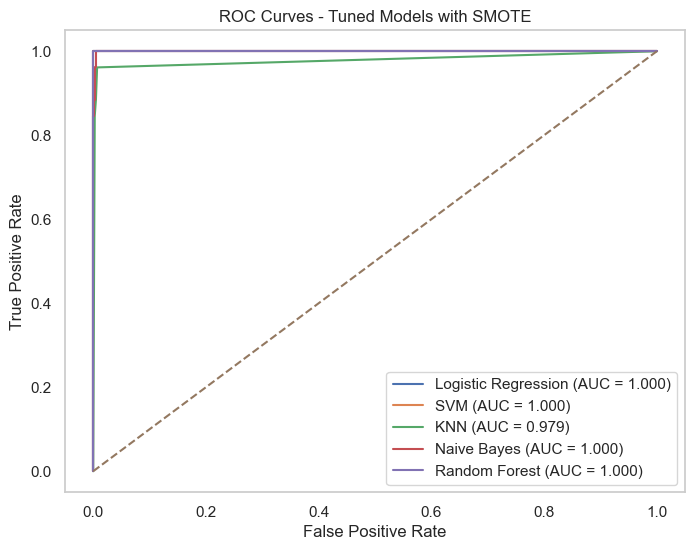

In [16]:
plt.figure(figsize=(8,6))

for name, pipe in best_models.items():
    y_prob = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curves - Tuned Models with SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

## 9. Feature importance

Logistic Regression and (linear) SVM coefficients are on scaled features, so their sizes are comparable across features. Random Forest importance values sum to 1. KNN and Naive Bayes do not provide comparable importances.

In [17]:
# Feature importance from the tuned models
importance = {}

lr = best_models["Logistic Regression"].named_steps["model"]
importance["Logistic Regression (coefficient)"] = lr.coef_[0]

svm = best_models["SVM"].named_steps["model"]
if svm.kernel == "linear":          # coefficients exist only for a linear kernel
    importance["SVM (coefficient)"] = svm.coef_[0]

rf = best_models["Random Forest"].named_steps["model"]
importance["Random Forest (importance)"] = rf.feature_importances_

pd.DataFrame(importance, index=features).round(3)

,Logistic Regression (coefficient),SVM (coefficient),Random Forest (importance)
Rainfall_mm,23.819,14.451,0.694
WaterLevel_m,-0.151,-0.049,0.131
SoilMoisture_pct,0.437,0.173,0.174
Elevation_m,0.132,0.126,0.001


## Notes

- The test set has 26 flood events out of 1,462 records, so a single mistake moves precision and F1 noticeably.
- Scores this close to perfect suggest the flood label is largely determined by these four inputs. See the limitations section of the README.